# **LIBRARIES**

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns # Đẹp hơn matplotlib

# **GIỚI THIỆU DỮ LIỆU**
### **Về nguồn data**: 
- **Source**: World Development Indicators (WDI) là một nguồn dữ liệu do Ngân hàng Thế giới (World Bank) cung cấp.
- Các tập dataset được lựa chọn thông qua việc gộp các trường dữ liệu (Series) có chung Tên trường chính (ví dụ: 'Life Expectancy + (male/female/all),...'), Kiểu dữ liệu và lấy tất cả 
### **Về từng tập dataset**:
#### 1. `Life_Exp_Data.csv`: Life Expectancy (Tuổi thọ người dân)
1. Tổng quan:
- Bộ dữ liệu này cung cấp chỉ số tuổi thọ trung bình tại thời điểm sinh (life expectancy at birth) của dân số theo từng quốc gia, được phân chia theo giới tính (nam, nữ và tổng thể), từ năm 1960 → 2023.

2. Các cột chính:
- `Country Name`: Tên quốc gia
- `Country Code`: Mã quốc gia theo chuẩn ISO
- `Series Name`: Tên định danh, gồm loại:
    + Life expectancy at birth, female (years)
    + Life expectancy at birth, male (years)
    + Life expectancy at birth, total (years)
- `Series Code`: Mã chỉ số tương ứng, ví dụ:
    + SP.DYN.LE00.FE.IN (nữ)
    + SP.DYN.LE00.MA.IN (nam)
    + SP.DYN.LE00.IN (tổng thể)
- `1960 [YR1960] → 2023 [YR2023]`: Giá trị tuổi thọ theo từng năm (dạng số thực, đơn vị: năm tuổi)

3. Kiểu dữ liệu:
- Dữ liệu được lưu dưới dạng chuỗi (object) để bao gồm cả giá trị thiếu (..).
- Các giá trị tuổi thọ là số thập phân đại diện cho số năm (ví dụ: 66.213 năm).

4. Đặc điểm nổi bật:
- Gồm dữ liệu cho 268 quốc gia, mỗi quốc gia có 3 dòng tương ứng với 3 chỉ số (nam, nữ, tổng thể).
- Thời gian bao phủ từ năm 1960 đến 2023, với dữ liệu dày và đầy đủ hơn trong các năm gần đây.
- Dữ liệu tuổi thọ nữ thường cao hơn tuổi thọ nam ở hầu hết quốc gia.
---

#### 2. `Death_rate_Data.csv`: Death Rate (Tỷ lệ tử vong)
1. Tổng quan:
- Bộ dữ liệu này cung cấp thông tin liên quan đến tỷ lệ tử vong thô (crude death rate) và số lượng người tử vong theo nhóm tuổi, từ năm 1960 đến 2023, phân theo quốc gia.

2. Các cột chính:
- `Country Name`: Tên quốc gia
- `Country Code`: Mã quốc gia theo chuẩn ISO
- `Series Name`: Tên định danh, bao gồm:
    – Death rate, crude (per 1,000 people)
    – Number of deaths ages 5-9 years
    – Number of deaths ages 10-14 years
    – Number of deaths ages 15-19 years
    – Number of deaths ages 20-24 years
- `Series Code`: Mã định danh của chỉ số, ví dụ: SP.DYN.CDRT.IN, SH.DTH.0509, SH.DTH.1014,...
- `1960 [YR1960] → 2023 [YR2023]`: Giá trị số tương ứng theo từng năm (dạng số thập phân hoặc ..)

3. Kiểu dữ liệu:
- Các cột dữ liệu được lưu ở dạng chuỗi (object) do có chứa giá trị thiếu (..).
- Dữ liệu có thể là:
    + Số thực biểu thị tỷ lệ tử vong (ví dụ: 7.344)
    + Số nguyên biểu thị số ca tử vong (ví dụ: 4169)

4. Đặc điểm nổi bật
- Bao gồm dữ liệu cho 268 quốc gia, mỗi quốc gia có nhiều dòng dữ liệu, tương ứng với từng nhóm tuổi tử vong.
- Các nhóm tuổi bao phủ từ 5 đến 24 tuổi, chia theo 5 năm.
---
#### 3. `GDP_Data.csv`: GDP 
1. Tổng quan:
Bộ dữ liệu này tổng hợp nhiều chỉ số GDP liên quan đến kinh tế vĩ mô của các quốc gia từ năm 1974 đến 2023. Các chỉ số này phản ánh quy mô, tốc độ tăng trưởng và sự thay đổi của GDP theo thời gian, dưới nhiều đơn vị tính khác nhau.

2. Các cột chính:
- `Country Name`:	Tên quốc gia
- `Country Code`:	Mã quốc gia (ISO)
- `Series Name`: Tên định danh GDP, ví dụ:
    + GDP (constant 2015 US$)
    + GDP (current US$)
    + GDP deflator, v.v.
- `Series Code`: Mã định danh của chỉ số, ví dụ: NY.GDP.MKTP.KD, NY.GDP.MKTP.CD, NY.GDP.DEFL.ZS,...
- `1974 [YR1974] → 2023 [YR2023]`: Giá trị theo từng năm, thường ở dạng số thực hoặc .. nếu thiếu dữ liệu

3. Kiểu dữ liệu:
- Toàn bộ các cột đều là kiểu chuỗi (object) để tương thích với các ô thiếu dữ liệu (..).
- Dữ liệu bao gồm cả giá trị số thập phân và ký hiệu khoa học (ví dụ: 5.00575565E+15).

4. Đặc điểm nổi bật:
- Bao gồm 20 chỉ số GDP khác nhau trên 268 quốc gia.
- Mỗi quốc gia có nhiều dòng tương ứng với từng chỉ số.
- Thời gian bao phủ từ năm 1974 đến 2023.

5. Một số chỉ số thường gặp:
- GDP (constant 2015 US$) – GDP đã điều chỉnh theo lạm phát
- GDP (current US$) – GDP danh nghĩa theo USD hiện tại
- GDP deflator – chỉ số điều chỉnh giá theo từng nước

In [2]:
# Nhập dữ liệu từ các file csv
file_paths = [
    "Data/Life_Expectancy/Life_Exp_Data.csv",
    "Data/Death_rate/Death_rate_Data.csv",
    "Data/GDP/GDP_Data.csv"
]

# Đọc dữ liệu từ các file csv
life_exp_df = pd.read_csv(file_paths[0])
death_rate_df = pd.read_csv(file_paths[1])
gdp_df = pd.read_csv(file_paths[2])

# Hiển thị thông tin cũa từng tập dữ liệu
print(life_exp_df.info())
print(death_rate_df.info())
print(gdp_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 803 entries, 0 to 802
Data columns (total 68 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   800 non-null    object
 1   Country Code   798 non-null    object
 2   Series Name    798 non-null    object
 3   Series Code    798 non-null    object
 4   1960 [YR1960]  798 non-null    object
 5   1961 [YR1961]  798 non-null    object
 6   1962 [YR1962]  798 non-null    object
 7   1963 [YR1963]  798 non-null    object
 8   1964 [YR1964]  798 non-null    object
 9   1965 [YR1965]  798 non-null    object
 10  1966 [YR1966]  798 non-null    object
 11  1967 [YR1967]  798 non-null    object
 12  1968 [YR1968]  798 non-null    object
 13  1969 [YR1969]  798 non-null    object
 14  1970 [YR1970]  798 non-null    object
 15  1971 [YR1971]  798 non-null    object
 16  1972 [YR1972]  798 non-null    object
 17  1973 [YR1973]  798 non-null    object
 18  1974 [YR1974]  798 non-null   

In [3]:
# Hiển thị 5 dòng đầu của từng tập dữ liệu
print(life_exp_df.head())
print(death_rate_df.head())
print(gdp_df.head())

  Country Name Country Code                               Series Name  \
0  Afghanistan          AFG  Life expectancy at birth, female (years)   
1  Afghanistan          AFG    Life expectancy at birth, male (years)   
2  Afghanistan          AFG   Life expectancy at birth, total (years)   
3      Albania          ALB  Life expectancy at birth, female (years)   
4      Albania          ALB    Life expectancy at birth, male (years)   

         Series Code 1960 [YR1960] 1961 [YR1961] 1962 [YR1962] 1963 [YR1963]  \
0  SP.DYN.LE00.FE.IN        33.285        33.813        34.297        34.773   
1  SP.DYN.LE00.MA.IN         31.87        32.409        32.883        33.346   
2     SP.DYN.LE00.IN        32.535        33.068        33.547        34.016   
3  SP.DYN.LE00.FE.IN         57.78          58.9         59.75        60.831   
4  SP.DYN.LE00.MA.IN        51.365        52.618         53.82        55.071   

  1964 [YR1964] 1965 [YR1965]  ... 2014 [YR2014] 2015 [YR2015] 2016 [YR2016]  \


In [4]:
# Mô tả dữ liệu
print(life_exp_df.describe())
print(death_rate_df.describe())
print(gdp_df.describe())

       Country Name Country Code                               Series Name  \
count           800          798                                       798   
unique          268          266                                         3   
top     Afghanistan          AFG  Life expectancy at birth, female (years)   
freq              3            3                                       266   

              Series Code 1960 [YR1960] 1961 [YR1961] 1962 [YR1962]  \
count                 798           798           798           798   
unique                  3           737           742           741   
top     SP.DYN.LE00.FE.IN            ..            ..            ..   
freq                  266            42            39            39   

       1963 [YR1963] 1964 [YR1964] 1965 [YR1965]  ... 2014 [YR2014]  \
count            798           798           798  ...           798   
unique           737           734           743  ...           736   
top               ..            ..      

# **TIỀN XỬ LÝ**

## **Tiền xử lý chung**: vì các dataset có trùng nhiều thông tin cột nên có thể được tiền xử lý chung các bước sau
- Bỏ các cột không cần thiết cho mục đích phân tích như `Series Code`
- Chuyển định dạng dữ liệu rộng → dài (wide to long) bằng cách:
    + Giữ lại 3 cột chính: `Country Name`, `Series Name`
    + Gộp các cột năm thành 2 cột: `Year` (dạng số) và `Value` (giá trị chỉ số)
- Làm sạch cột Year: Trích xuất 4 chữ số từ tên cột (ví dụ: từ 2020 [YR2020] → 2020)
- Chuyển đổi dữ liệu Value sang kiểu số (float), các giá trị như .. sẽ tự động trở thành NaN

In [5]:
def preprocess_basic_all(df):
    # Bỏ cột 'Series Code' vì không cần thiết
    df = df.drop(columns=["Series Code", "Country Code"])
    
    # Melt dữ liệu để chuyển các cột năm thành một cột 'Year' và giá trị tương ứng thành cột 'Value'
    # id_vars: các cột giữ nguyên
    # var_name: tên cột chứa năm
    # value_name: tên cột chứa giá trị
    df_melted = df.melt(
        id_vars=["Country Name", "Series Name"],
        var_name="Year",
        value_name="Value"
    )

    # Chuyển cột 'Year' sang kiểu số nguyên bằng cách lấy 4 kí tự cuối cùng
    df_melted["Year"] = df_melted["Year"].str.extract(r"(\d{4})").astype(int)

    # Chuyển cột 'Value' sang kiểu số (nếu trống thì thành NaN)
    df_melted["Value"] = pd.to_numeric(df_melted["Value"], errors="coerce")
    
    return df_melted

# Tiền xử lý dữ liệu chung
life_exp_long = preprocess_basic_all(life_exp_df)
death_rate_long = preprocess_basic_all(death_rate_df)
gdp_long = preprocess_basic_all(gdp_df)


In [6]:
# Đếm số giá trị thiếu của từng cột
print(life_exp_long.isnull().sum())
print(death_rate_long.isnull().sum())
print(gdp_long.isnull().sum())

Country Name     192
Series Name      320
Year               0
Value           3020
dtype: int64
Country Name      192
Series Name       320
Year                0
Value           41523
dtype: int64
Country Name      150
Series Name       250
Year                0
Value           84254
dtype: int64


### **Xử lý missing data**: vì lượng missing data trong từng dataset là khác nhau và phức tạp nên cần sử dụng nhiều phương pháp khác nhau để xử lý, nếu drop hết thì sẽ không thực tế, ảnh hưởng tới kết quả cuối cùng nhiều.

- Cách xử lý missing data đã thực hiện:
    + Nếu > 50% dữ liệu trong một năm bị thiếu → Loại bỏ cả năm đó
    + Nếu ≤ 50% dữ liệu bị thiếu → Giữ lại năm đó và sau này có thể điền bằng phương pháp toán học (như interpolation, nhóm trung bình, v.v.)

- Các giá trị bị thiếu còn lại được điền bằng chiến lược hai bước như sau:
    + Bước 1: interpolation theo Quốc gia - `Country Name` và `Series Name`: 
        + Với mỗi quốc gia và từng dòng dữ liệu (ví dụ: "GDP (current US$)"), các giá trị bị thiếu được interpolation tuyến tính theo thời gian để phản ánh xu hướng tại địa phương.
        + Phương pháp interpolation (interpolation): linear với tham số limit_direction='both'
    + Bước 2: Điền các giá trị NaN còn lại bằng giá trị trung bình của `Series-Year`, gọi là `Global Series-Year Mean`:
        + Một số nhóm có toàn bộ dữ liệu bị thiếu (ví dụ: không có dữ liệu GDP cho một quốc gia trong bất kỳ năm nào).
        + Các giá trị `NaN` còn lại này được điền bằng giá trị trung bình của tất cả các quốc gia cho cùng `Series Name` và Năm - `Year`.

> ***Đảm bảo rằng không còn điểm dữ liệu nào bị thiếu sau khi xử lý, đồng thời xu hướng global giúp duy trì tính thực tế của dữ liệu.*** 

In [7]:
# Hàm kiểm tra tỷ lệ giá trị thiếu data theo năm
def missing_ratio_by_year(df, threshold=0.5):
    missing_per_year = df.groupby("Year")["Value"].apply(lambda x: x.isna().mean())
    to_drop = missing_per_year[missing_per_year > threshold].index.tolist()
    to_keep = df[~df["Year"].isin(to_drop)] # ~: not để đỡ tốn vòng lặp
    return to_keep, to_drop, missing_per_year

# Tính tỷ lệ giá trị thiếu data theo năm
life_exp_filled, dropped_years_life, missing_ratio_life = missing_ratio_by_year(life_exp_long)
death_rate_filled, dropped_years_death, missing_ratio_death = missing_ratio_by_year(death_rate_long)
gdp_filled, dropped_years_gdp, missing_ratio_gdp = missing_ratio_by_year(gdp_long)

# Hiển thị tỷ lệ giá trị thiếu data theo năm
dropped_years_summary = {
    "Life Expectancy": dropped_years_life,
    "Death Rate": dropped_years_death,
    "GDP": dropped_years_gdp
}

dropped_years_summary

{'Life Expectancy': [2023],
 'Death Rate': [1960,
  1961,
  1962,
  1963,
  1964,
  1965,
  1966,
  1967,
  1968,
  1969,
  1970,
  1971,
  1972,
  1973,
  1974,
  1975,
  1976,
  1977,
  1978,
  1979,
  1980,
  1981,
  1982,
  1983,
  1984,
  1985,
  1986,
  1987,
  1988,
  1989,
  2023],
 'GDP': [1974,
  1975,
  1976,
  1977,
  1978,
  1979,
  1980,
  1981,
  1982,
  1983,
  1984,
  1985,
  1986,
  1987,
  1988,
  1989]}

In [8]:
# Nhìn lại dữ liệu sau khi xử lý giá trị thiếu
life_exp_filled.info()
death_rate_filled.info()
gdp_filled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50589 entries, 0 to 50588
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  50400 non-null  object 
 1   Series Name   50274 non-null  object 
 2   Year          50589 non-null  int32  
 3   Value         48372 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 1.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 52833 entries, 48030 to 100862
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  52734 non-null  object 
 1   Series Name   52668 non-null  object 
 2   Year          52833 non-null  int32  
 3   Value         48879 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 1.8+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 181050 entries, 85200 to 266249
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtyp

- Các năm đã bị loại bỏ vì thiếu quá nhiều dữ liệu:
1. Life Expectancy (`Life_Exp_Data.csv`):
> Dropped years: [2023]

2. Death Rate (`Death_rate_Data.csv`):
> Dropped years: [1960 → 1989, 2023] → do phần lớn chỉ số tử vong nhóm tuổi chỉ có dữ liệu từ 1990 trở đi

3. GDP (`GDP_Data.csv`):
> Dropped years: [1974 → 1989] → phần lớn quốc gia thiếu dữ liệu GDP trong các năm đầu

In [9]:
# Sử dụng hàm interpolate để điền giá trị thiếu dữ liệu theo xu hướng của từng quốc gia 
def fill_missing_by_country_trend(df):
    # Interpolate giá trị thiếu dữ liệu theo xu hướng của từng quốc gia
    # Sắp xếp dữ liệu theo 'Country Name', 'Series Name', 'Year'
    df = df.sort_values(by=["Country Name", "Series Name", "Year"])
    df["Value"] = df.groupby(["Country Name", "Series Name"])["Value"].transform( 
        lambda x: x.interpolate(method='linear', limit_direction='both') # theo xu hướng tuyến tính 
    )

    # Nếu còn giá trị thiếu sau khi interpolate thì điền bằng giá trị trung bình của cùng Series Name và Year
    missing_mask = df["Value"].isna()
    fill_value = df.groupby(["Series Name", "Year"])["Value"].transform("mean")
    df.loc[missing_mask, "Value"] = fill_value[missing_mask]    

    return df

# Điền giá trị thiếu dữ liệu theo xu hướng của từng quốc gia
life_exp_filled = fill_missing_by_country_trend(life_exp_filled)
death_rate_filled = fill_missing_by_country_trend(death_rate_filled)
gdp_filled = fill_missing_by_country_trend(gdp_filled)

In [10]:
# Kiểm tra lại dữ liệu sau khi điền giá trị thiếu
life_exp_filled.info()
death_rate_filled.info()
gdp_filled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50589 entries, 0 to 50586
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  50400 non-null  object 
 1   Series Name   50274 non-null  object 
 2   Year          50589 non-null  int32  
 3   Value         50274 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 1.7+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 52833 entries, 48030 to 100860
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  52734 non-null  object 
 1   Series Name   52668 non-null  object 
 2   Year          52833 non-null  int32  
 3   Value         52668 non-null  float64
dtypes: float64(1), int32(1), object(2)
memory usage: 1.8+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 181050 entries, 85220 to 266247
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtyp

In [11]:
# Luu dữ liệu đã xử lý
life_exp_filled.to_csv("Data/Life_Expectancy/Life_Exp_Data_Processed.csv", index=False)
death_rate_filled.to_csv("Data/Death_rate/Death_rate_Data_Processed.csv", index=False)
gdp_filled.to_csv("Data/GDP/GDP_Data_Processed.csv", index=False)

# **PHÂN TÍCH DỮ LIỆU**

In [12]:
# Group dữ liệu theo 'Country Name' và 'Year' để vẽ biểu đồ
life_exp_grouped = life_exp_filled.groupby(["Country Name", "Year"])["Value"].mean().reset_index()
death_rate_grouped = death_rate_filled.groupby(["Country Name", "Year"])["Value"].mean().reset_index()
gdp_grouped = gdp_filled.groupby(["Country Name", "Year"])["Value"].mean().reset_index()

relevant_country_names = ["Vietnam", "United States", "China", "Japan", "Germany", "United Kingdom", "France", "India", "Brazil", "Canada"]

# Lấy dữ liệu năm gần nhất để phân tích tương quan và chênh lệch
latest_year = life_exp_grouped['Year'].max()
life_exp_latest = life_exp_grouped[life_exp_grouped['Year'] == latest_year]
death_rate_latest = death_rate_grouped[death_rate_grouped['Year'] == latest_year]
gdp_latest = gdp_grouped[gdp_grouped['Year'] == latest_year]

# Kết hợp dữ liệu để phân tích tương quan
merged_data = pd.merge(life_exp_latest[['Country Name', 'Value']], 
                       death_rate_latest[['Country Name', 'Value']], 
                       on='Country Name', 
                       suffixes=('_LifeExp', '_DeathRate'))
merged_data = pd.merge(merged_data, 
                       gdp_latest[['Country Name', 'Value']], 
                       on='Country Name')
merged_data.rename(columns={'Value': 'Value_GDP'}, inplace=True)


### **Mục tiêu 1: Xu hướng tuổi thọ trung bình qua thời gian**

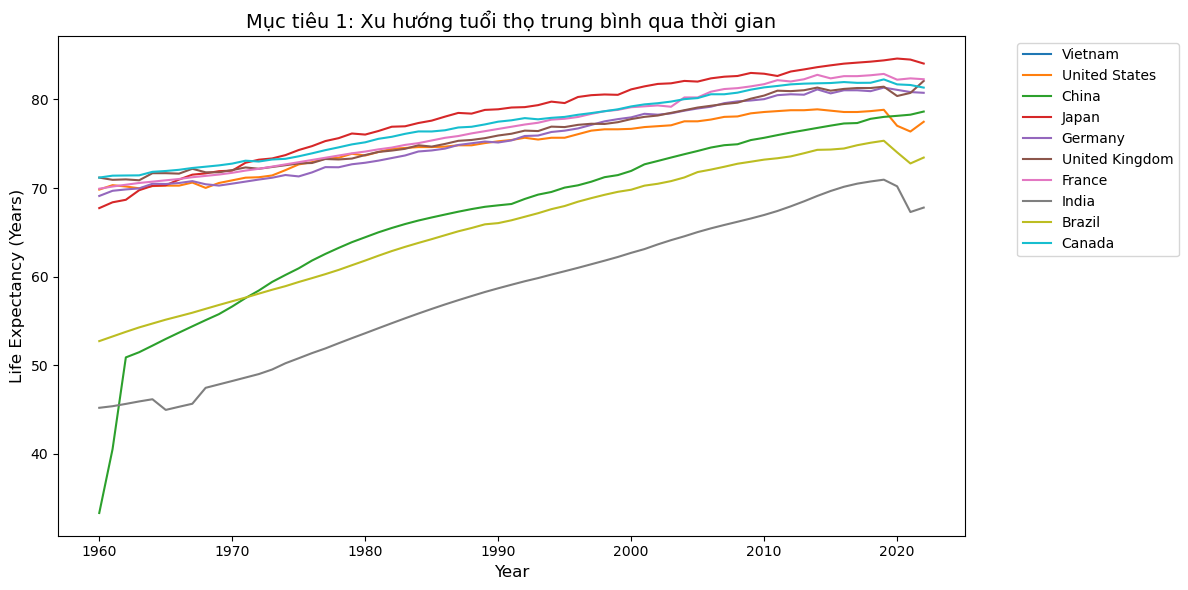

In [13]:
plt.figure(figsize=(12, 6))
for country in relevant_country_names:
    country_data = life_exp_grouped[life_exp_grouped['Country Name'] == country]
    plt.plot(country_data['Year'], country_data['Value'], label=country)
plt.title('Mục tiêu 1: Xu hướng tuổi thọ trung bình qua thời gian', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Life Expectancy (Years)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ đường (Line Plot)
- **Lý do:**
  - **Tính chất dữ liệu:** Dữ liệu tuổi thọ trung bình (Value) thay đổi theo thời gian (Year) cho từng quốc gia. Đây là - dữ liệu dạng time-series, và biểu đồ đường là lựa chọn lý tưởng để thể hiện xu hướng thay đổi liên tục qua thời gian.
  - **Mục tiêu phân tích:** Làm rõ xu hướng tăng/giảm của tuổi thọ trung bình qua các năm, giúp dễ dàng so sánh giữa các quốc gia.

#### **Nhận xét**

## 1. Tổng quan

* **Trục X (Year):** Biểu thị thời gian từ năm 1960 đến năm 2020.
* **Trục Y (Life Expectancy):** Biểu thị tuổi thọ trung bình của người dân tại các quốc gia.
* **Màu sắc:** Mỗi quốc gia được biểu thị bằng một đường màu khác nhau.

## 2. Xu hướng chung

* **Tăng trưởng ổn định:**
    * Hầu hết các quốc gia đều có xu hướng tăng tuổi thọ trung bình qua thời gian, phản ánh sự cải thiện trong điều kiện sống, y tế, và kinh tế.
    * Các quốc gia phát triển như Japan, Canada, Germany, United States, United Kingdom, France có tuổi thọ trung bình cao và ổn định hơn so với các quốc gia đang phát triển.
* **Khoảng cách giữa các quốc gia:**
    * Có sự chênh lệch rõ rệt về tuổi thọ trung bình giữa các quốc gia phát triển (như Japan, Canada) và các quốc gia đang phát triển (như India, Vietnam, Brazil) trong giai đoạn đầu (1960-1980).
    * Tuy nhiên, khoảng cách này dần thu hẹp từ những năm 2000 trở đi.

## 3. Phân tích theo quốc gia

* **a. Japan:**
    * Japan có tuổi thọ trung bình cao nhất trong tất cả các quốc gia, vượt mốc 80 năm từ khoảng năm 2000.
    * Điều này phản ánh hệ thống y tế tiên tiến, chế độ dinh dưỡng lành mạnh, và lối sống khoa học của người dân Nhật Bản.
* **b. Canada, Germany, United Kingdom, France, United States:**
    * Các quốc gia phát triển này có xu hướng tăng trưởng ổn định và đạt tuổi thọ trung bình trên 80 năm vào khoảng năm 2010.
    * Sự ổn định này phản ánh hệ thống y tế tốt, mức sống cao, và các chính sách xã hội hiệu quả.
* **c. Vietnam:**
    * Vietnam có sự tăng trưởng đáng kể về tuổi thọ trung bình, từ khoảng 50 năm (1960) lên gần 75 năm (2020).
    * Điều này cho thấy sự cải thiện mạnh mẽ trong y tế, dinh dưỡng, và điều kiện sống sau các giai đoạn khó khăn trong lịch sử.
* **d. China:**
    * China có sự tăng trưởng mạnh mẽ từ khoảng 45 năm (1960) lên gần 77 năm (2020).
    * Sự cải thiện này phản ánh sự phát triển kinh tế nhanh chóng và các chính sách y tế công cộng hiệu quả.
* **e. India:**
    * India bắt đầu với tuổi thọ trung bình thấp nhất (dưới 40 năm vào năm 1960) nhưng đã tăng lên gần 70 năm vào năm 2020.
    * Tuy nhiên, tuổi thọ của India vẫn thấp hơn so với các quốc gia khác, cho thấy còn nhiều thách thức về y tế và điều kiện sống.
* **f. Brazil:**
    * Brazil có xu hướng tăng trưởng ổn định, từ khoảng 50 năm (1960) lên gần 75 năm (2020), tương tự như Vietnam.

## 4. Các giai đoạn nổi bật

* **a. Giai đoạn 1960-1980:**
    * Các quốc gia phát triển (Japan, Canada, Germany, ...) đã có tuổi thọ trung bình cao (trên 70 năm), trong khi các quốc gia đang phát triển (India, Vietnam, Brazil) có tuổi thọ trung bình thấp hơn (dưới 60 năm).
    * Đây là giai đoạn mà sự chênh lệch giữa các quốc gia phát triển và đang phát triển rõ rệt nhất.
* **b. Giai đoạn 1980-2000:**
    * Các quốc gia đang phát triển như Vietnam, China, và Brazil có sự tăng trưởng nhanh chóng về tuổi thọ trung bình, thu hẹp khoảng cách với các quốc gia phát triển.
* **c. Giai đoạn 2000-2020:**
    * Tuổi thọ trung bình của hầu hết các quốc gia đều ổn định ở mức cao (trên 70 năm).
    * Các quốc gia phát triển tiếp tục duy trì tuổi thọ trung bình trên 80 năm.

### **Mục tiêu 2: Xu hướng tỷ lệ tử vong qua thời gian**

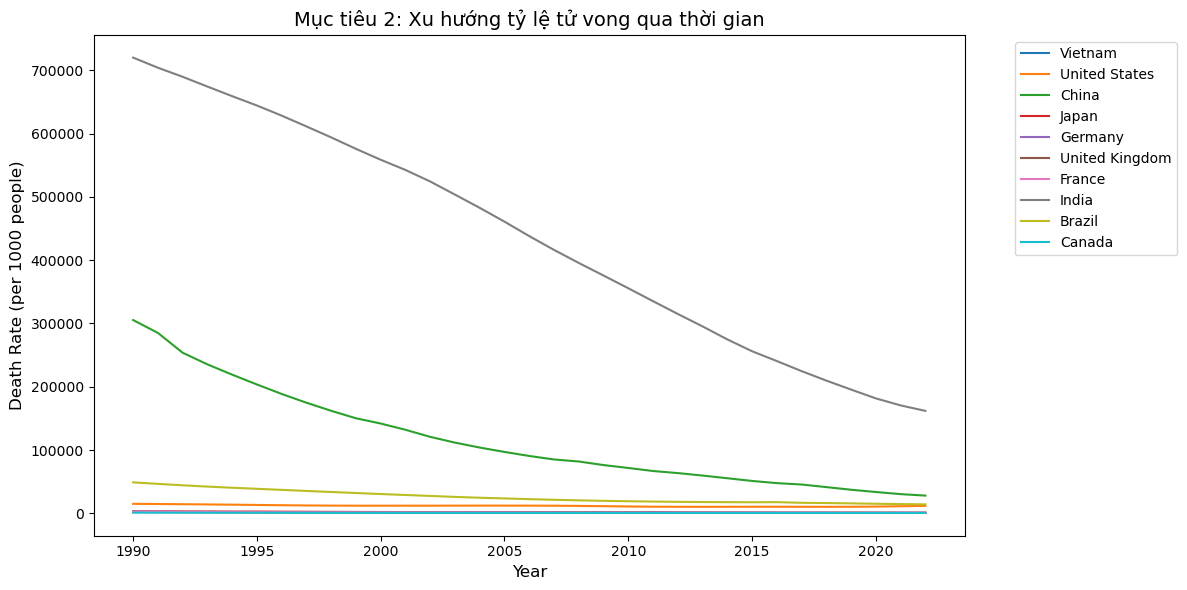

In [14]:
plt.figure(figsize=(12, 6))
for country in relevant_country_names:
    country_data = death_rate_grouped[death_rate_grouped['Country Name'] == country]
    plt.plot(country_data['Year'], country_data['Value'], label=country)
plt.title('Mục tiêu 2: Xu hướng tỷ lệ tử vong qua thời gian', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Death Rate (per 1000 people)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ đường (Line Plot)
- **Lý do:**
  - **Tính chất dữ liệu:** Tương tự Mục tiêu 1, tỷ lệ tử vong (Value) cũng là dữ liệu time-series, thay đổi theo Year cho từng quốc gia.
  - **Mục tiêu phân tích:** Hiển thị xu hướng thay đổi của tỷ lệ tử vong qua thời gian, giúp nhận diện các quốc gia có tỷ lệ tử vong tăng hoặc giảm.

#### Phân tích biểu đồ: Mục tiêu 2: Xu hướng tỷ lệ tử vong qua thời gian

#### 1. Tổng quan

* **Trục X (Year - Năm):** Biểu thị thời gian từ năm 1990 đến năm 2020.
* **Trục Y (Death Rate - Tỷ lệ tử vong):** Biểu thị tỷ lệ tử vong trên 1.000 người dân.
* **Màu sắc:** Mỗi quốc gia được biểu diễn bằng một đường màu riêng biệt, giúp dễ dàng so sánh xu hướng giữa các quốc gia.


#### 2. Xu hướng chung

* **Giảm dần:** Hầu hết các quốc gia đều cho thấy xu hướng giảm tỷ lệ tử vong trong giai đoạn từ 1990 đến 2020. Điều này cho thấy sự tiến bộ trong chăm sóc sức khỏe, điều kiện sống và các biện pháp y tế công cộng.
* **Sự khác biệt lớn:** Có sự chênh lệch rõ rệt về tỷ lệ tử vong giữa các quốc gia. India có tỷ lệ tử vong cao nhất, trong khi các quốc gia phát triển như Nhật Bản, Đức và Canada có tỷ lệ tử vong thấp hơn nhiều.

#### 3. Phân tích theo quốc gia

* **India (Đường màu xám):**
    * Có tỷ lệ tử vong cao nhất trong tất cả các quốc gia, đặc biệt là trong những năm đầu (trên 700.000 người chết trên 1.000 người).
    * Tuy nhiên, tỷ lệ này đã giảm đáng kể theo thời gian, cho thấy sự cải thiện trong các lĩnh vực như chăm sóc sức khỏe và dinh dưỡng.
* **China (Đường màu cam):**
    * Có tỷ lệ tử vong cao thứ hai sau India.
    * Cũng cho thấy xu hướng giảm đáng kể theo thời gian, có thể là kết quả của sự phát triển kinh tế và các chính sách y tế công cộng.
* **Các quốc gia phát triển (Vietnam, United States, Japan, Germany, United Kingdom, France, Brazil, Canada):**
    * Tỷ lệ tử vong thấp và tương đối ổn định trong suốt giai đoạn.
    * Điều này phản ánh hệ thống y tế tốt, điều kiện sống cao và các chính sách xã hội hiệu quả.

#### 4. Các giai đoạn nổi bật

* **1990 - 2000:** Tỷ lệ tử vong giảm nhanh ở các quốc gia đang phát triển như India và China.
* **2000 - 2010:** Xu hướng giảm tiếp tục, đặc biệt là ở các quốc gia đang phát triển. Khoảng cách về tỷ lệ tử vong giữa các quốc gia phát triển và đang phát triển thu hẹp lại.
* **2010 - 2020:** Tỷ lệ tử vong tiếp tục giảm, nhưng với tốc độ chậm hơn. Các quốc gia phát triển duy trì tỷ lệ tử vong rất thấp.

#### 5. Ảnh hưởng của đại dịch COVID-19

* **Tác động toàn cầu:** Đại dịch COVID-19, bắt đầu vào cuối năm 2019 và lan rộng vào năm 2020, đã có tác động đáng kể đến tỷ lệ tử vong trên toàn cầu.
* **Tăng tỷ lệ tử vong:** Đại dịch đã dẫn đến sự gia tăng đáng kể tỷ lệ tử vong ở nhiều quốc gia, đặc biệt là ở những quốc gia có hệ thống y tế kém phát triển hoặc dân số già.
* **Ảnh hưởng không đồng đều:** Tác động của đại dịch không đồng đều giữa các quốc gia. Một số quốc gia đã kiểm soát dịch bệnh tốt hơn và có tỷ lệ tử vong thấp hơn, trong khi những quốc gia khác phải đối mặt với số ca tử vong cao.
* **Ảnh hưởng lâu dài:** Đại dịch COVID-19 có thể có những ảnh hưởng lâu dài đến tỷ lệ tử vong, không chỉ do số ca tử vong trực tiếp do virus mà còn do các tác động gián tiếp như gián đoạn dịch vụ y tế và suy thoái kinh tế.

#### 6. Các yếu tố khác

* **Phát triển y tế:** Tiến bộ trong y học, cải thiện hệ thống chăm sóc sức khỏe.
* **Điều kiện sống:** Cải thiện vệ sinh, dinh dưỡng, giảm nghèo đói.
* **Chính sách y tế công cộng:** Chương trình tiêm chủng, kiểm soát dịch bệnh, giáo dục sức khỏe.
* **Các yếu tố khác:** Tuổi thọ trung bình, thảm họa tự nhiên, chiến tranh.

### **Mục tiêu 3: Xu hướng GDP qua thời gian**

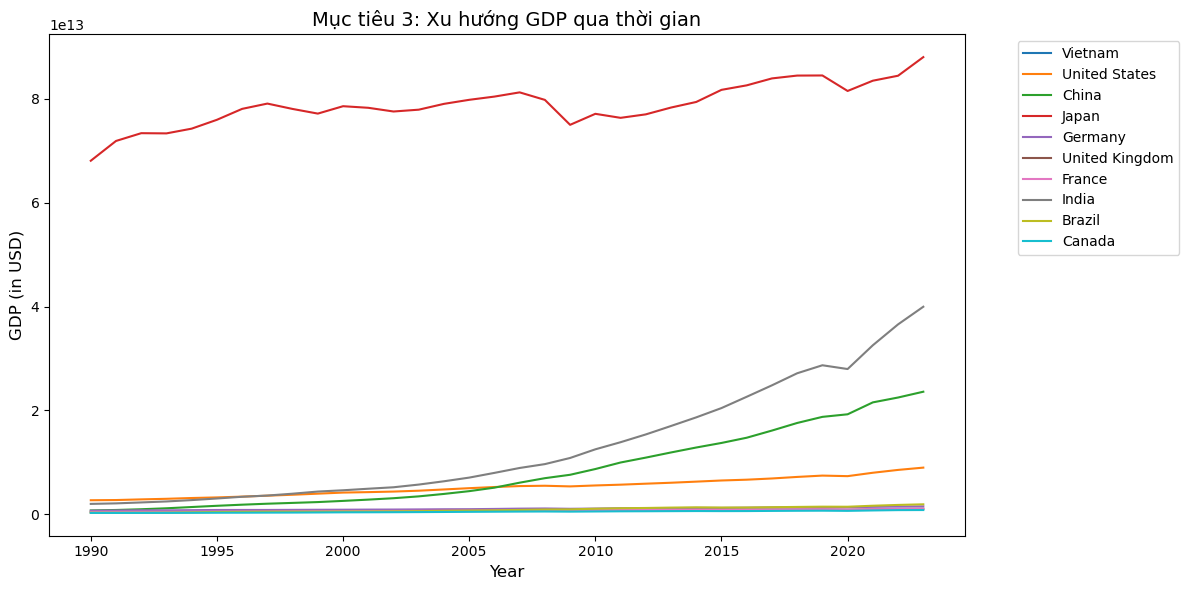

In [15]:
plt.figure(figsize=(12, 6))
for country in relevant_country_names:
    country_data = gdp_grouped[gdp_grouped['Country Name'] == country]
    plt.plot(country_data['Year'], country_data['Value'], label=country)
plt.title('Mục tiêu 3: Xu hướng GDP qua thời gian', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP (in USD)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ đường (Line Plot)
- **Lý do:**
  - **Tính chất dữ liệu:** GDP (Value) cũng là dữ liệu time-series, thay đổi theo Year.
  - **Mục tiêu phân tích:** Hiển thị xu hướng tăng trưởng hoặc suy giảm GDP qua thời gian, giúp so sánh sự phát triển kinh tế giữa các quốc gia.

#### **Nhận xét**
#### 1. Tổng quan

* **Trục X (Year - Năm):** Biểu thị thời gian từ năm 1990 đến năm 2020.
* **Trục Y (GDP in USD - GDP tính theo USD):** Biểu thị Tổng sản phẩm quốc nội (GDP) của các quốc gia, đơn vị tính là đô la Mỹ.
* **Màu sắc:** Mỗi quốc gia được biểu diễn bằng một đường màu riêng biệt, giúp dễ dàng so sánh xu hướng tăng trưởng GDP giữa các quốc gia.

#### 2. Xu hướng chung

* **Tăng trưởng chung:** Hầu hết các quốc gia đều cho thấy xu hướng tăng trưởng GDP trong giai đoạn từ 1990 đến 2020, mặc dù tốc độ tăng trưởng khác nhau.
* **Sự phân hóa rõ rệt:** Có sự phân hóa rõ rệt về quy mô GDP giữa các quốc gia. Các quốc gia phát triển như Hoa Kỳ, Nhật Bản và Đức có GDP cao hơn nhiều so với các quốc gia đang phát triển như Ấn Độ và Việt Nam.

#### 3. Phân tích theo quốc gia

* **Hoa Kỳ (Đường màu cam):**
    * Có GDP cao nhất trong tất cả các quốc gia, cho thấy vị thế kinh tế hàng đầu thế giới.
    * Tăng trưởng ổn định trong suốt giai đoạn, mặc dù có thể có những biến động nhỏ do khủng hoảng kinh tế hoặc các yếu tố khác.
* **Nhật Bản (Đường màu đỏ):**
    * Có GDP cao thứ hai sau Hoa Kỳ.
    * Tăng trưởng chậm hơn so với Hoa Kỳ trong giai đoạn này, có thể do các vấn đề kinh tế trong nước.
* **Trung Quốc (Đường màu xanh lá cây):**
    * Cho thấy sự tăng trưởng mạnh mẽ nhất trong tất cả các quốc gia, đặc biệt là trong những năm gần đây.
    * Sự tăng trưởng này phản ánh sự phát triển kinh tế nhanh chóng của Trung Quốc.
* **Ấn Độ (Đường màu xám):**
    * Cũng cho thấy sự tăng trưởng đáng kể, mặc dù quy mô GDP vẫn còn thấp hơn so với các quốc gia phát triển.
    * Sự tăng trưởng này phản ánh sự phát triển kinh tế của Ấn Độ.
* **Các quốc gia khác (Việt Nam, Đức, Anh, Pháp, Brazil, Canada):**
    * Có GDP thấp hơn so với các quốc gia phát triển.
    * Tăng trưởng GDP của các quốc gia này khác nhau. Ví dụ, Việt Nam cho thấy sự tăng trưởng ổn định, trong khi Brazil có những biến động lớn hơn.

#### 4. Các giai đoạn nổi bật

* **1990 - 2000:** Các quốc gia phát triển tăng trưởng ổn định, trong khi các quốc gia đang phát triển bắt đầu cho thấy sự tăng trưởng.
* **2000 - 2010:** Trung Quốc tăng trưởng mạnh mẽ, trở thành nền kinh tế lớn thứ hai thế giới.
* **2010 - 2020:** Ấn Độ tiếp tục tăng trưởng, trong khi các quốc gia phát triển có những biến động do khủng hoảng kinh tế và các yếu tố khác.

#### 5. Kết luận

* Biểu đồ cho thấy sự phân hóa rõ rệt về quy mô GDP giữa các quốc gia phát triển và đang phát triển.
* Trung Quốc đã có sự tăng trưởng mạnh mẽ nhất trong giai đoạn này, cho thấy sự trỗi dậy của nền kinh tế này.
* Các quốc gia đang phát triển khác như Ấn Độ và Việt Nam cũng cho thấy sự tăng trưởng đáng kể, mặc dù quy mô GDP vẫn còn thấp hơn so với các quốc gia phát triển.
* Các quốc gia phát triển có GDP cao, nhưng tốc độ tăng trưởng chậm hơn so với các quốc gia đang phát triển.

### **Mục tiêu 4: Tương quan giữa GDP và tuổi thọ trung bình**

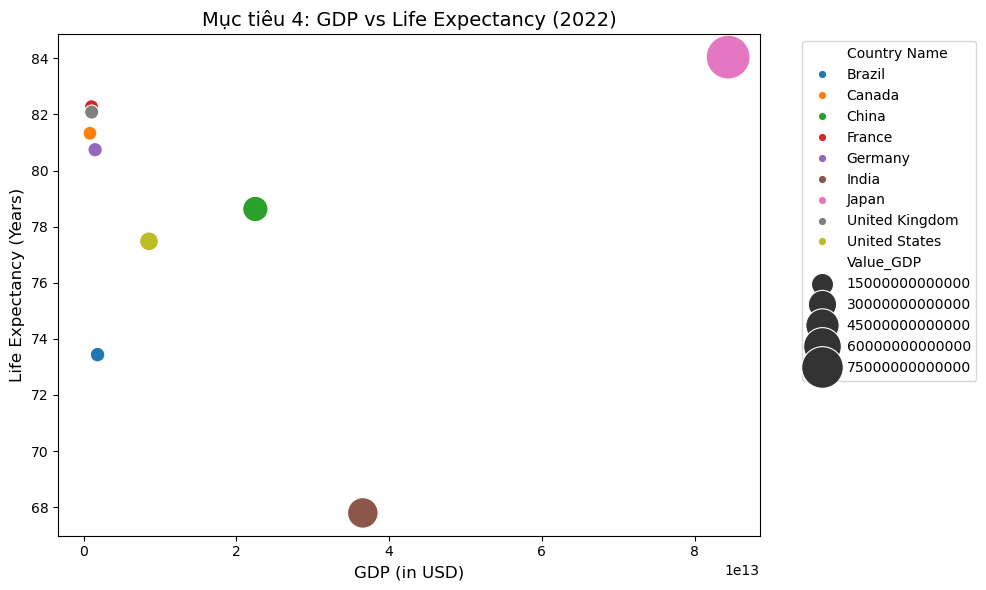

Mục tiêu 4: Hệ số tương quan giữa GDP và Life Expectancy năm 2022: 0.04


In [16]:
# Lấy dữ liệu năm 2022 (hoặc năm gần nhất nếu 2022 không có dữ liệu)
target_year = 2022
if target_year not in life_exp_grouped['Year'].values or target_year not in gdp_grouped['Year'].values:
    target_year = max(life_exp_filtered['Year'].max(), gdp_filtered['Year'].max())
    print(f"Năm 2022 không có dữ liệu, sử dụng năm gần nhất: {target_year}")

life_exp_latest = life_exp_grouped[life_exp_grouped['Year'] == target_year]
gdp_latest = gdp_grouped[gdp_grouped['Year'] == target_year]

# Kết hợp dữ liệu và lọc lại để chỉ lấy các quốc gia trong relevant_country_names
merged_data = pd.merge(life_exp_latest[['Country Name', 'Value']], 
                       gdp_latest[['Country Name', 'Value']], 
                       on='Country Name', 
                       suffixes=('_LifeExp', '_GDP'))
merged_data = merged_data[merged_data['Country Name'].isin(relevant_country_names)]

# Kiểm tra nếu merged_data rỗng
if merged_data.empty:
    print(f"Không có dữ liệu cho năm {target_year} với các quốc gia đã chọn.")
else:
    # Vẽ biểu đồ phân tán
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=merged_data, x='Value_GDP', y='Value_LifeExp', hue='Country Name', size='Value_GDP', sizes=(100, 1000))
    plt.title(f'Mục tiêu 4: GDP vs Life Expectancy ({target_year})', fontsize=14)
    plt.xlabel('GDP (in USD)', fontsize=12)
    plt.ylabel('Life Expectancy (Years)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # Tính hệ số tương quan
    correlation_4 = merged_data['Value_GDP'].corr(merged_data['Value_LifeExp'])
    print(f"Mục tiêu 4: Hệ số tương quan giữa GDP và Life Expectancy năm {target_year}: {correlation_4:.2f}")

#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ phân tán (Scatter Plot)
- **Lý do:**
  - **Tính chất dữ liệu:** Dữ liệu ở đây là hai biến định lượng (GDP và tuổi thọ trung bình) trong một năm cụ thể (target_year). Chúng ta cần xem mối quan hệ giữa hai biến này.
  - **Mục tiêu phân tích:** Xác định xem GDP có ảnh hưởng đến tuổi thọ trung bình hay không (tương quan). Biểu đồ phân tán là lựa chọn tốt nhất để thể hiện mối quan hệ giữa hai biến số, đặc biệt khi kết hợp với hệ số tương quan (correlation coefficient).

#### **Nhận xét**
#### 1. Tổng quan

* **Trục X (GDP in USD):** Biểu thị Tổng sản phẩm quốc nội (GDP) của các quốc gia, đơn vị tính là đô la Mỹ.
* **Trục Y (Life Expectancy - Tuổi thọ trung bình):** Biểu thị tuổi thọ trung bình của người dân tại các quốc gia, đơn vị tính là năm.
* **Kích thước điểm dữ liệu:** Kích thước của mỗi điểm dữ liệu thể hiện giá trị GDP của quốc gia đó. Điểm càng lớn, GDP càng cao.
* **Màu sắc:** Mỗi quốc gia được biểu diễn bằng một màu sắc riêng biệt, giúp dễ dàng phân biệt và so sánh giữa các quốc gia.

#### 2. Xu hướng chung

* **Tương quan dương:** Nhìn chung, có một xu hướng tương quan dương giữa GDP và tuổi thọ trung bình. Các quốc gia có GDP cao hơn thường có tuổi thọ trung bình cao hơn.
* **Sự phân hóa rõ rệt:** Có sự phân hóa rõ rệt về GDP và tuổi thọ trung bình giữa các quốc gia. Các quốc gia phát triển như Hoa Kỳ, Nhật Bản và Canada có GDP và tuổi thọ trung bình cao hơn so với các quốc gia đang phát triển như Ấn Độ và Brazil.

#### 3. Phân tích theo quốc gia

* **Hoa Kỳ (Đường màu vàng):** Có GDP cao nhất và tuổi thọ trung bình cao thứ hai trong số các quốc gia được liệt kê. Điều này cho thấy mối quan hệ chặt chẽ giữa phát triển kinh tế và tuổi thọ trung bình.
* **Nhật Bản (Đường màu hồng):** Có GDP cao thứ hai và tuổi thọ trung bình cao nhất trong số các quốc gia được liệt kê. Điều này cho thấy Nhật Bản đã đạt được những thành tựu đáng kể trong việc cải thiện sức khỏe và tuổi thọ của người dân.
* **Canada (Đường màu cam):** Có GDP và tuổi thọ trung bình cao, tương tự như Hoa Kỳ và Nhật Bản.
* **Các quốc gia châu Âu (Đức, Pháp, Anh):** Có GDP và tuổi thọ trung bình tương đối cao, cho thấy sự phát triển kinh tế và xã hội ổn định.
* **Trung Quốc (Đường màu xanh lá cây):** Có GDP tương đối cao nhưng tuổi thọ trung bình thấp hơn so với các quốc gia phát triển. Điều này có thể là do các vấn đề về môi trường và hệ thống y tế.
* **Ấn Độ (Đường màu xám):** Có GDP và tuổi thọ trung bình thấp nhất trong số các quốc gia được liệt kê. Điều này cho thấy Ấn Độ vẫn còn nhiều thách thức trong việc cải thiện kinh tế và sức khỏe của người dân.
* **Brazil (Đường màu xanh dương):** Có GDP và tuổi thọ trung bình ở mức trung bình, cho thấy sự phát triển kinh tế và xã hội ở mức độ trung bình.

#### 4. Kết luận

* Biểu đồ cho thấy mối quan hệ tương quan dương giữa GDP và tuổi thọ trung bình. Các quốc gia có GDP cao hơn thường có tuổi thọ trung bình cao hơn.
* Tuy nhiên, vẫn có những ngoại lệ. Ví dụ, Trung Quốc có GDP tương đối cao nhưng tuổi thọ trung bình thấp hơn so với các quốc gia phát triển.
* Điều này cho thấy rằng GDP không phải là yếu tố duy nhất ảnh hưởng đến tuổi thọ trung bình. Các yếu tố khác như hệ thống y tế, môi trường và lối sống cũng đóng vai trò quan trọng.

### **Mục tiêu 5: Tương quan giữa GDP và tỷ lệ tử vong**

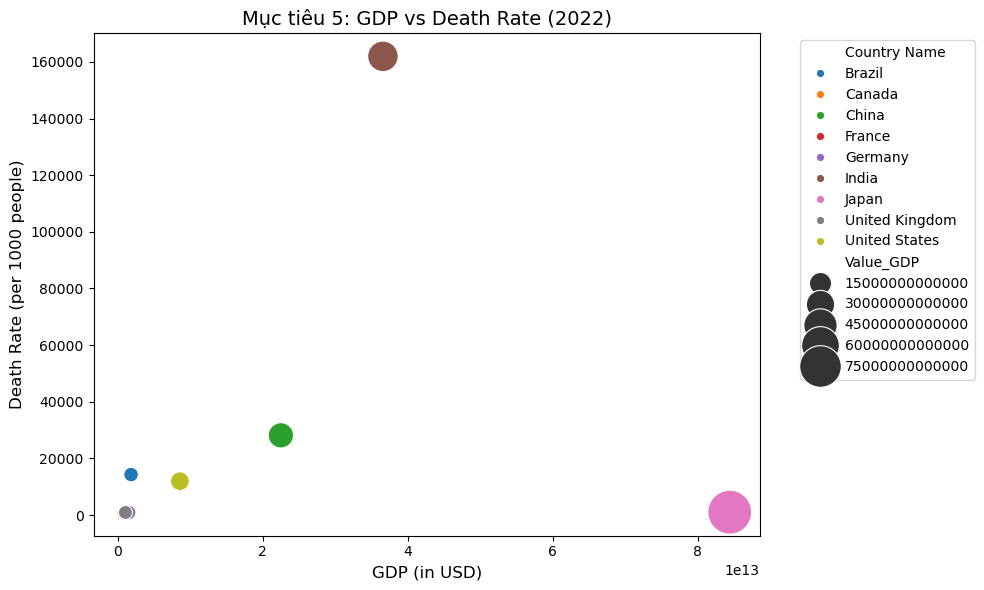

Mục tiêu 5: Hệ số tương quan giữa GDP và Death Rate năm 2022: 0.25


In [17]:
death_rate_latest = death_rate_grouped[death_rate_grouped['Year'] == target_year]
merged_data = pd.merge(merged_data, 
                       death_rate_latest[['Country Name', 'Value']], 
                       on='Country Name')
merged_data.rename(columns={'Value': 'Value_DeathRate'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_data, x='Value_GDP', y='Value_DeathRate', hue='Country Name', size='Value_GDP', sizes=(100, 1000))
plt.title(f'Mục tiêu 5: GDP vs Death Rate ({target_year})', fontsize=14)
plt.xlabel('GDP (in USD)', fontsize=12)
plt.ylabel('Death Rate (per 1000 people)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
correlation_5 = merged_data['Value_GDP'].corr(merged_data['Value_DeathRate'])
print(f"Mục tiêu 5: Hệ số tương quan giữa GDP và Death Rate năm {target_year}: {correlation_5:.2f}")

#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ phân tán (Scatter Plot)
- **Lý do:**
  - **Tính chất dữ liệu:** Dữ liệu tuổi thọ trung bình (Value) thay đổi theo thời gian (Year) cho từng quốc gia. Đây là - dữ liệu dạng time-series, và biểu đồ đường là lựa chọn lý tưởng để thể hiện xu hướng thay đổi liên tục qua thời gian.
  - **Mục tiêu phân tích:** Làm rõ xu hướng tăng/giảm của tuổi thọ trung bình qua các năm, giúp dễ dàng so sánh giữa các quốc gia.

#### **Nhận xét**
#### 1. Tổng quan

* **Trục X (GDP in USD):** Biểu thị Tổng sản phẩm quốc nội (GDP) của các quốc gia, đơn vị tính là đô la Mỹ.
* **Trục Y (Death Rate - Tỷ lệ tử vong):** Biểu thị tỷ lệ tử vong trên 1.000 người dân tại các quốc gia.
* **Kích thước điểm dữ liệu:** Kích thước của mỗi điểm dữ liệu thể hiện giá trị GDP của quốc gia đó. Điểm càng lớn, GDP càng cao.
* **Màu sắc:** Mỗi quốc gia được biểu diễn bằng một màu sắc riêng biệt, giúp dễ dàng phân biệt và so sánh giữa các quốc gia.

#### 2. Xu hướng chung

* **Không có mối tương quan rõ ràng:** Không có mối tương quan rõ ràng giữa GDP và tỷ lệ tử vong trong biểu đồ này. Các quốc gia có GDP cao không nhất thiết có tỷ lệ tử vong thấp hơn, và ngược lại.
* **Sự phân hóa lớn:** Có sự phân hóa lớn về tỷ lệ tử vong giữa các quốc gia, ngay cả khi GDP tương tự.

#### 3. Phân tích theo quốc gia

* **Ấn Độ (Đường màu tím):** Có GDP thấp nhất và tỷ lệ tử vong cao nhất trong số các quốc gia được liệt kê. Điều này cho thấy Ấn Độ vẫn còn nhiều thách thức trong việc cải thiện sức khỏe và điều kiện sống của người dân.
* **Trung Quốc (Đường màu xanh lá cây):** Có GDP tương đối cao nhưng tỷ lệ tử vong cũng tương đối cao. Điều này có thể là do các vấn đề về môi trường và hệ thống y tế.
* **Các quốc gia phát triển (Hoa Kỳ, Nhật Bản, Canada, Đức, Pháp, Anh):** Có GDP cao hơn và tỷ lệ tử vong dao động. Một số quốc gia có tỷ lệ tử vong thấp hơn (ví dụ: Nhật Bản), trong khi một số quốc gia khác có tỷ lệ tử vong cao hơn (ví dụ: Hoa Kỳ).
* **Brazil (Đường màu xanh dương):** Có GDP và tỷ lệ tử vong ở mức trung bình.

#### 4. Kết luận

* Biểu đồ cho thấy rằng GDP không phải là yếu tố duy nhất ảnh hưởng đến tỷ lệ tử vong. Các yếu tố khác như hệ thống y tế, môi trường và lối sống cũng đóng vai trò quan trọng.
* Các quốc gia phát triển có GDP cao hơn, nhưng điều này không đảm bảo tỷ lệ tử vong thấp hơn.
* Các quốc gia đang phát triển như Ấn Độ vẫn còn nhiều thách thức trong việc cải thiện sức khỏe và điều kiện sống của người dân.

### **Mục tiêu 6: Tương quan giữa tuổi thọ trung bình và tỷ lệ tử vong**

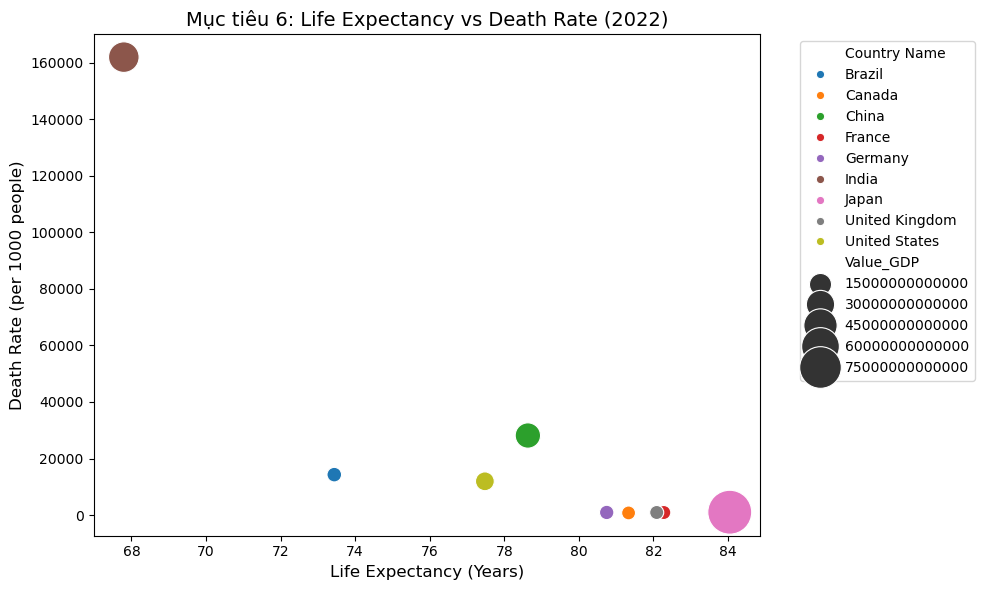

Mục tiêu 6: Hệ số tương quan giữa Life Expectancy và Death Rate năm 2022: -0.85


In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_data, x='Value_LifeExp', y='Value_DeathRate', hue='Country Name', size='Value_GDP', sizes=(100, 1000))
plt.title(f'Mục tiêu 6: Life Expectancy vs Death Rate ({target_year})', fontsize=14)
plt.xlabel('Life Expectancy (Years)', fontsize=12)
plt.ylabel('Death Rate (per 1000 people)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
correlation_6 = merged_data['Value_LifeExp'].corr(merged_data['Value_DeathRate'])
print(f"Mục tiêu 6: Hệ số tương quan giữa Life Expectancy và Death Rate năm {target_year}: {correlation_6:.2f}")

#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ phân tán (Scatter Plot)
- **Lý do:**
  - **Tính chất dữ liệu:** Hai biến định lượng (tuổi thọ trung bình và tỷ lệ tử vong) trong một năm cụ thể.ai biến định lượng (tuổi thọ trung bình và tỷ lệ tử vong) trong một năm cụ thể.
  - **Mục tiêu phân tích:** Xác định mối quan hệ giữa tuổi thọ trung bình và tỷ lệ tử vong, ví dụ: liệu tuổi thọ cao có liên quan đến tỷ lệ tử vong thấp hay không.

#### **Nhận xét**
#### 1. Tổng quan

* **Trục X (Life Expectancy - Tuổi thọ trung bình):** Biểu thị tuổi thọ trung bình của người dân tại các quốc gia, đơn vị tính là năm.
* **Trục Y (Death Rate - Tỷ lệ tử vong):** Biểu thị tỷ lệ tử vong trên 1.000 người dân tại các quốc gia.
* **Kích thước điểm dữ liệu:** Kích thước của mỗi điểm dữ liệu thể hiện giá trị GDP của quốc gia đó. Điểm càng lớn, GDP càng cao.
* **Màu sắc:** Mỗi quốc gia được biểu diễn bằng một màu sắc riêng biệt, giúp dễ dàng phân biệt và so sánh giữa các quốc gia.

#### 2. Xu hướng chung

* **Tương quan âm:** Nhìn chung, có một xu hướng tương quan âm giữa tuổi thọ trung bình và tỷ lệ tử vong. Các quốc gia có tuổi thọ trung bình cao hơn thường có tỷ lệ tử vong thấp hơn.
* **Sự phân hóa rõ rệt:** Có sự phân hóa rõ rệt về tuổi thọ trung bình và tỷ lệ tử vong giữa các quốc gia. Các quốc gia phát triển có tuổi thọ trung bình cao và tỷ lệ tử vong thấp hơn so với các quốc gia đang phát triển.

#### 3. Phân tích theo quốc gia

* **Ấn Độ (Đường màu tím):** Có tuổi thọ trung bình thấp nhất và tỷ lệ tử vong cao nhất trong số các quốc gia được liệt kê. Điều này cho thấy Ấn Độ vẫn còn nhiều thách thức trong việc cải thiện sức khỏe và điều kiện sống của người dân.
* **Trung Quốc (Đường màu xanh lá cây):** Có tuổi thọ trung bình tương đối thấp và tỷ lệ tử vong tương đối cao. Điều này có thể là do các vấn đề về môi trường và hệ thống y tế.
* **Các quốc gia phát triển (Hoa Kỳ, Nhật Bản, Canada, Đức, Pháp, Anh):** Có tuổi thọ trung bình cao hơn và tỷ lệ tử vong thấp hơn. Nhật Bản có tuổi thọ trung bình cao nhất và tỷ lệ tử vong thấp nhất trong số các quốc gia được liệt kê.
* **Brazil (Đường màu xanh dương):** Có tuổi thọ trung bình và tỷ lệ tử vong ở mức trung bình.

#### 4. Kết luận

* Biểu đồ cho thấy mối quan hệ tương quan âm giữa tuổi thọ trung bình và tỷ lệ tử vong. Các quốc gia có tuổi thọ trung bình cao hơn thường có tỷ lệ tử vong thấp hơn.
* Các quốc gia phát triển có tuổi thọ trung bình cao và tỷ lệ tử vong thấp hơn so với các quốc gia đang phát triển.
* Các quốc gia đang phát triển như Ấn Độ vẫn còn nhiều thách thức trong việc cải thiện sức khỏe và điều kiện sống của người dân.

### **Mục tiêu 7: Chênh lệch tuổi thọ trung bình giữa các quốc gia**

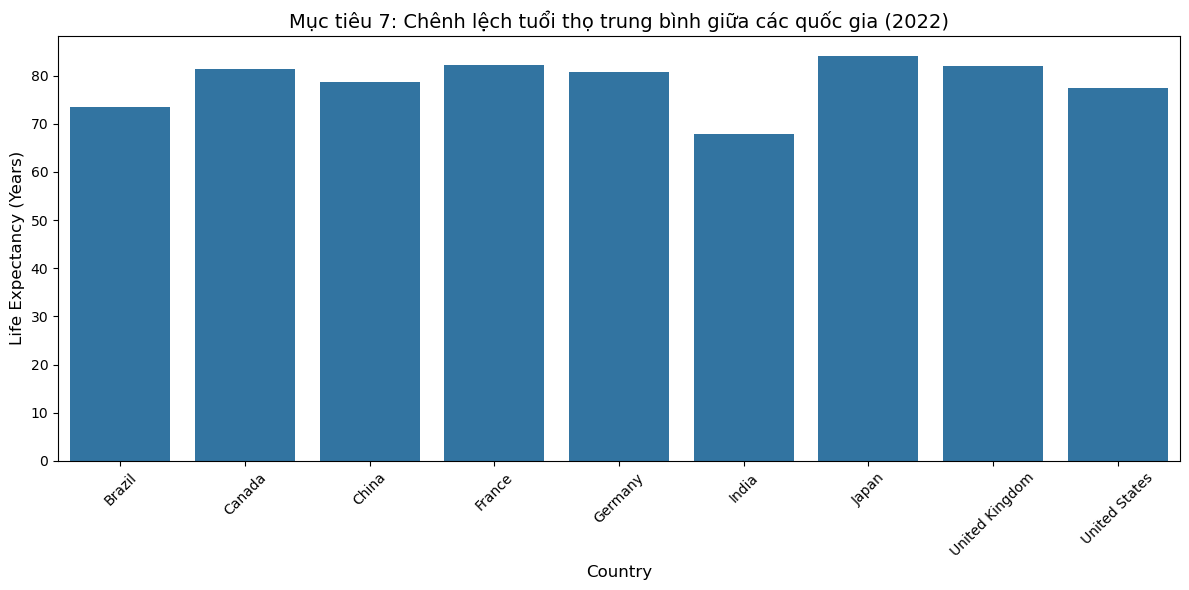

In [19]:
# Đảm bảo life_exp_latest chỉ chứa các quốc gia trong relevant_country_names
life_exp_latest = life_exp_grouped[life_exp_grouped['Year'] == target_year]
life_exp_latest = life_exp_latest[life_exp_latest['Country Name'].isin(relevant_country_names)]

plt.figure(figsize=(12, 6))
sns.barplot(data=life_exp_latest, x='Country Name', y='Value')
plt.title(f'Mục tiêu 7: Chênh lệch tuổi thọ trung bình giữa các quốc gia ({target_year})', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Life Expectancy (Years)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ cột (Bar Plot)
- **Lý do:**
  - **Tính chất dữ liệu:** Dữ liệu là tuổi thọ trung bình (Value) của từng quốc gia (Country Name) trong một năm cụ thể. Đây là dữ liệu định lượng (tuổi thọ) được so sánh giữa các nhóm (quốc gia - categorical).
  - **Mục tiêu phân tích:** So sánh trực quan tuổi thọ trung bình giữa các quốc gia, giúp nhận diện quốc gia nào có tuổi thọ cao nhất/thấp nhất.

#### **Nhận xét**
## 1. Tổng quan

* **Trục X (Life Expectancy - Tuổi thọ trung bình):** Biểu thị tuổi thọ trung bình của người dân tại các quốc gia, đơn vị tính là năm.
* **Trục Y (Death Rate - Tỷ lệ tử vong):** Biểu thị tỷ lệ tử vong trên 1.000 người dân tại các quốc gia.
* **Kích thước điểm dữ liệu:** Kích thước của mỗi điểm dữ liệu thể hiện giá trị GDP của quốc gia đó. Điểm càng lớn, GDP càng cao.
* **Màu sắc:** Mỗi quốc gia được biểu diễn bằng một màu sắc riêng biệt, giúp dễ dàng phân biệt và so sánh giữa các quốc gia.


## 2. Xu hướng chung

* Tuổi thọ trung bình cao ở các quốc gia phát triển:

    * Các quốc gia phát triển như Japan, Canada, Germany, France, United Kingdom, United States có tuổi thọ trung bình cao hơn, dao động từ 78 đến 84 năm.
    * Japan dẫn đầu với tuổi thọ trung bình cao nhất, khoảng 84 năm.
* Tuổi thọ trung bình thấp hơn ở các quốc gia đang phát triển:

    * Các quốc gia đang phát triển như India, Brazil, China có tuổi thọ trung bình thấp hơn, dao động từ 70 đến 77 năm.
    * India có tuổi thọ trung bình thấp nhất, khoảng 70 năm, phản ánh các thách thức về y tế và điều kiện sống.

## 3. Phân tích theo quốc gia

* **a. Japan:**
    * Japan có tuổi thọ trung bình cao nhất (khoảng 84 năm), phản ánh hệ thống y tế tiên tiến, chế độ dinh dưỡng lành mạnh, và lối sống khoa học.
    * Đây là quốc gia có tuổi thọ trung bình cao nhất thế giới, nhờ vào các chính sách y tế công cộng hiệu quả và chăm sóc sức khỏe người cao tuổi.
* **b. Canada, Germany, France, United Kingdom, United States:**
    * Các quốc gia phát triển này có tuổi thọ trung bình cao, dao động từ 78 đến 82 năm.
    * Điều này phản ánh mức sống cao, hệ thống y tế tốt, và các chính sách xã hội hiệu quả.
    * United States có tuổi thọ trung bình thấp hơn một chút so với các quốc gia phát triển khác, có thể do bất bình đẳng trong tiếp cận y tế và các vấn đề sức khỏe cộng đồng như béo phì.
* **c. China:**
    * China có tuổi thọ trung bình khoảng 77 năm, cao hơn so với các quốc gia đang phát triển khác như India và Brazil.
    * Sự cải thiện này phản ánh sự phát triển kinh tế nhanh chóng và các chính sách y tế công cộng hiệu quả trong những thập kỷ gần đây.
* **d. Brazil:**
    * Brazil có tuổi thọ trung bình khoảng 75 năm, thấp hơn so với các quốc gia phát triển nhưng cao hơn India.
    * Điều này cho thấy sự cải thiện trong y tế và điều kiện sống, nhưng vẫn còn nhiều thách thức như bất bình đẳng xã hội và các vấn đề y tế công cộng.
* **e. India:**
    * India có tuổi thọ trung bình thấp nhất (khoảng 70 năm), phản ánh các thách thức lớn về y tế, dinh dưỡng, và điều kiện sống.
    * Mặc dù đã có sự cải thiện đáng kể trong những thập kỷ qua, India vẫn cần đầu tư nhiều hơn vào hệ thống y tế và các chính sách xã hội.
## 4. Kết luận

* Biểu đồ cho thấy mối quan hệ tương quan âm giữa tuổi thọ trung bình và tỷ lệ tử vong. Các quốc gia có tuổi thọ trung bình cao hơn thường có tỷ lệ tử vong thấp hơn.
* Các quốc gia phát triển có tuổi thọ trung bình cao và tỷ lệ tử vong thấp hơn so với các quốc gia đang phát triển.
* Các quốc gia đang phát triển như Ấn Độ vẫn còn nhiều thách thức trong việc cải thiện sức khỏe và điều kiện sống của người dân.


### **Mục tiêu 8: Chênh lệch tỷ lệ tử vong giữa các quốc gia**

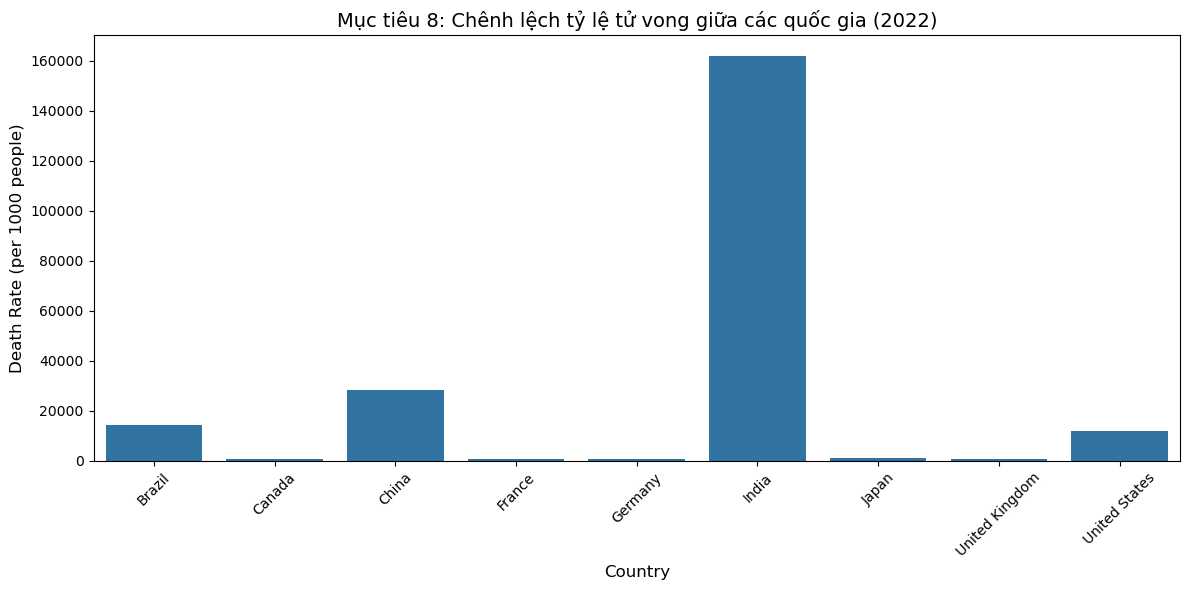

In [20]:
death_rate_latest = death_rate_grouped[death_rate_grouped['Year'] == target_year]
death_rate_latest = death_rate_latest[death_rate_latest['Country Name'].isin(relevant_country_names)]

plt.figure(figsize=(12, 6))
sns.barplot(data=death_rate_latest, x='Country Name', y='Value')
plt.title(f'Mục tiêu 8: Chênh lệch tỷ lệ tử vong giữa các quốc gia ({target_year})', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Death Rate (per 1000 people)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ cột (Bar Plot)
- **Lý do:**
  - **Tính chất dữ liệu:** Tương tự Mục tiêu 7, đây là dữ liệu định lượng (tỷ lệ tử vong) so sánh giữa các quốc gia (categorical).
  - **Mục tiêu phân tích:** So sánh tỷ lệ tử vong giữa các quốc gia, giúp nhận diện quốc gia nào có tỷ lệ tử vong cao nhất/thấp nhất.

#### **Nhận xét**

### **Mục tiêu 9: Tốc độ tăng trưởng GDP trung bình hàng năm**

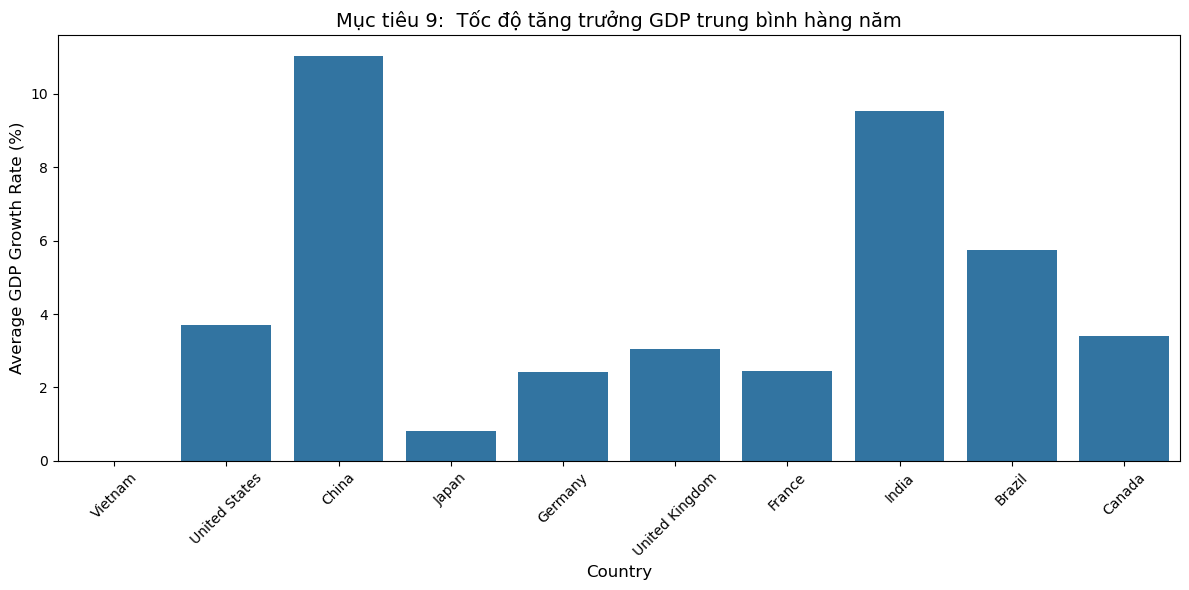

In [21]:
gdp_growth = {}
for country in relevant_country_names:
    country_data = gdp_grouped[gdp_grouped['Country Name'] == country].sort_values('Year')
    country_data['Growth Rate'] = country_data['Value'].pct_change() * 100
    avg_growth = country_data['Growth Rate'].mean()
    gdp_growth[country] = avg_growth

gdp_growth_df = pd.DataFrame.from_dict(gdp_growth, orient='index', columns=['Avg Growth Rate'])
gdp_growth_df.reset_index(inplace=True)
gdp_growth_df.rename(columns={'index': 'Country Name'}, inplace=True)

plt.figure(figsize=(12, 6))
sns.barplot(data=gdp_growth_df, x='Country Name', y='Avg Growth Rate')
plt.title('Mục tiêu 9:  Tốc độ tăng trưởng GDP trung bình hàng năm', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Average GDP Growth Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ cột (Bar Plot)
- **Lý do:**
  - **Tính chất dữ liệu:** Tốc độ tăng trưởng GDP trung bình (Avg Growth Rate) là dữ liệu định lượng, được tính cho từng quốc gia (categorical).
  - **Mục tiêu phân tích:** So sánh tốc độ tăng trưởng GDP giữa các quốc gia, giúp nhận diện quốc gia nào có tốc độ tăng trưởng cao nhất/thấp nhất.

#### **Nhận xét**

#### **1. Tổng quan**

- **Trục X (Country)**: Biểu thị tên các quốc gia.

- **Trục Y (Average GDP Growth Rate)**: Biểu thị tốc độ tăng trưởng GDP trung bình hàng năm (tính theo phần trăm).

- **Mục tiêu**: So sánh tốc độ tăng trưởng GDP trung bình giữa các quốc gia trong giai đoạn được phân tích.



#### **2. Xu hướng chung**

- **China và India dẫn đầu về tốc độ tăng trưởng GDP**:

- **China** có tốc độ tăng trưởng GDP trung bình cao nhất, vượt **10%/năm**, phản ánh sự phát triển kinh tế nhanh chóng và bền vững trong vài thập kỷ qua.

- **India** đứng thứ hai với tốc độ tăng trưởng GDP trung bình khoảng **6-7%/năm**, cho thấy sự phát triển mạnh mẽ của nền kinh tế đang nổi.


- **Các quốc gia phát triển có tốc độ tăng trưởng thấp hơn**:

    - Các quốc gia phát triển như **United States, Japan, Germany, United Kingdom, France, Canada** có tốc độ tăng trưởng GDP trung bình thấp hơn, dao động từ **1-3%/năm**.

    - Điều này phản ánh sự ổn định của các nền kinh tế phát triển, nơi tăng trưởng thường chậm hơn nhưng bền vững.



- **Brazil có tốc độ tăng trưởng trung bình khá**:
    - **Brazil** có tốc độ tăng trưởng GDP trung bình khoảng **3-4%/năm**, cao hơn các quốc gia phát triển nhưng thấp hơn so với các nền kinh tế đang nổi như China và India.


#### **3. Phân tích theo quốc gia**

#### **a. China**:

- **Tốc độ tăng trưởng GDP trung bình cao nhất (trên 10%)**:

    - Phản ánh sự phát triển kinh tế nhanh chóng trong vài thập kỷ qua, nhờ vào:

    - Chính sách cải cách kinh tế (Đổi mới và mở cửa từ năm 1978).

    - Đầu tư mạnh vào cơ sở hạ tầng, sản xuất, và xuất khẩu.

    - Quy mô dân số lớn, cung cấp lực lượng lao động dồi dào.



#### **b. India**:

- **Tốc độ tăng trưởng GDP trung bình cao thứ hai (khoảng 6-7%)**:

    - Phản ánh sự phát triển mạnh mẽ của nền kinh tế đang nổi, nhờ vào:

    - Dân số trẻ và lực lượng lao động lớn.

    - Sự phát triển trong các ngành công nghệ thông tin, dịch vụ, và sản xuất.

    - Cải cách kinh tế và chính sách thu hút đầu tư nước ngoài.


#### **c. Brazil**:

- **Tốc độ tăng trưởng GDP trung bình khá (khoảng 3-4%)**:

    - Phản ánh sự phát triển kinh tế ổn định, nhưng không bền vững như China và India.

    - Các vấn đề như bất bình đẳng kinh tế, tham nhũng, và phụ thuộc vào xuất khẩu hàng hóa đã kìm hãm tốc độ tăng trưởng.



#### **d. United States, United Kingdom, Germany, France, Canada**:

- **Tốc độ tăng trưởng GDP trung bình thấp (1-3%)**:

    - Phản ánh sự ổn định của các nền kinh tế phát triển, nơi tăng trưởng thường chậm hơn nhưng bền vững.

    - Các quốc gia này đã đạt đến mức phát triển cao, do đó tốc độ tăng trưởng GDP thường thấp hơn so với các nền kinh tế đang nổi.



#### **e. Japan**:

- **Tốc độ tăng trưởng GDP trung bình thấp nhất (dưới 1%)**:

    - Phản ánh các vấn đề kinh tế của Nhật Bản trong vài thập kỷ qua, bao gồm:

    - Tăng trưởng chậm sau "thập kỷ mất mát" (1990s).

    - Dân số già hóa và lực lượng lao động giảm.

    - Nợ công cao và sự phụ thuộc vào xuất khẩu.


### **4. Chênh lệch giữa các quốc gia**

- **Khoảng cách lớn giữa các nền kinh tế đang nổi và phát triển**:

    - Các nền kinh tế đang nổi như **China** và **India** có tốc độ tăng trưởng GDP trung bình cao hơn đáng kể so với các quốc gia phát triển.

    - Điều này phản ánh tiềm năng phát triển lớn của các nền kinh tế đang nổi, nơi cơ sở hạ tầng và công nghiệp hóa vẫn đang trong giai đoạn tăng trưởng.


- **Sự ổn định của các quốc gia phát triển**:

    - Các quốc gia phát triển có tốc độ tăng trưởng GDP trung bình thấp hơn nhưng ổn định, phản ánh sự bền vững của các nền kinh tế đã đạt đến mức phát triển cao.

#### 5. **Kết luận**

- Biểu đồ này cho thấy sự khác biệt rõ rệt về tốc độ tăng trưởng GDP trung bình hàng năm giữa các quốc gia. Các nền kinh tế đang nổi như **China** và **India** dẫn đầu với tốc độ tăng trưởng cao, trong khi các quốc gia phát triển như **United States**, **Japan**, và **Germany** có tốc độ tăng trưởng thấp hơn nhưng ổn định. Điều này phản ánh tiềm năng phát triển lớn của các nền kinh tế đang nổi, cũng như sự bền vững của các nền kinh tế phát triển.

### **Mục tiêu 10: Phân bố tuổi thọ trung bình giữa các quốc gia**

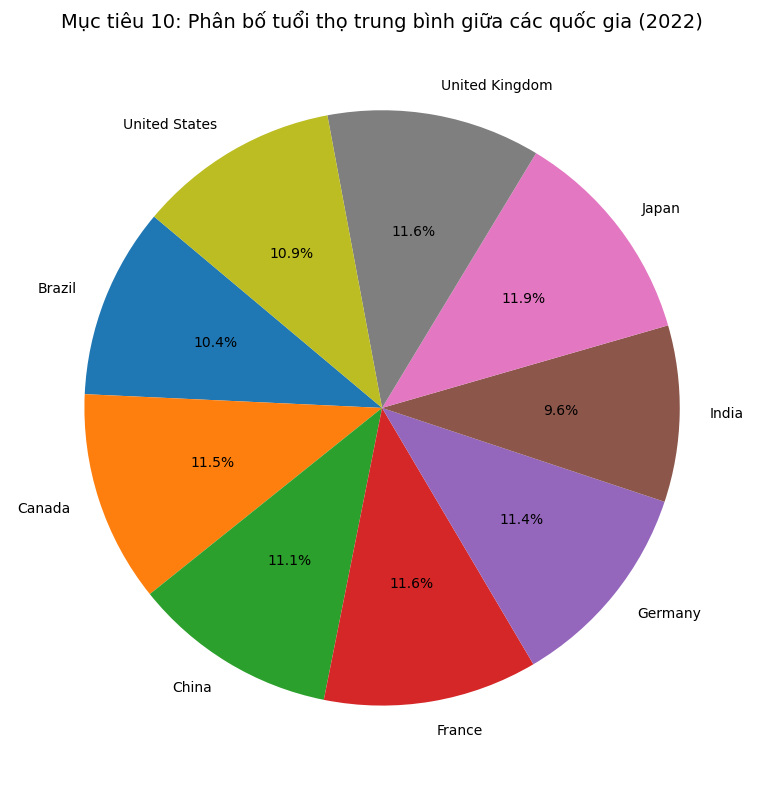

In [22]:
plt.figure(figsize=(8, 8))
plt.pie(life_exp_latest['Value'], labels=life_exp_latest['Country Name'], autopct='%1.1f%%', startangle=140)
plt.title(f'Mục tiêu 10: Phân bố tuổi thọ trung bình giữa các quốc gia ({target_year})', fontsize=14)
plt.tight_layout()
plt.show()

#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ tròn (Pie Chart)
- **Lý do:**
  - **Tính chất dữ liệu:** Dữ liệu là tuổi thọ trung bình (Value) của từng quốc gia trong một năm cụ thể, và chúng ta muốn xem tỷ lệ đóng góp của từng quốc gia vào tổng tuổi thọ trung bình.
  - **Mục tiêu phân tích:** Hiển thị phân bố tương đối của tuổi thọ trung bình giữa các quốc gia, giúp nhận diện quốc gia nào chiếm tỷ lệ lớn nhất.

#### **Nhận xét**

### **Mục tiêu 11: Phân bố tỷ lệ tử vong giữa các quốc gia**

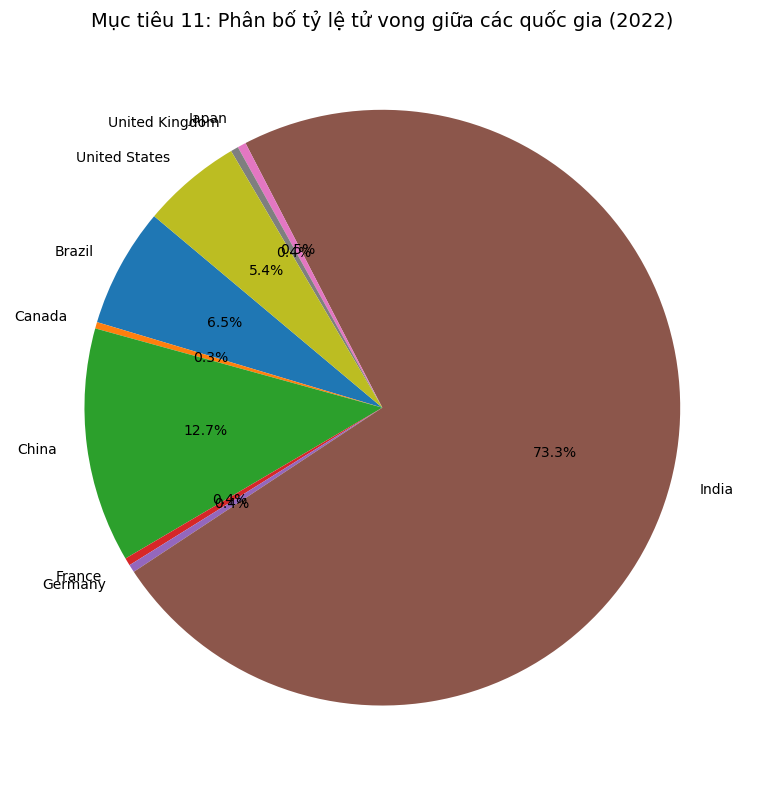

In [23]:
plt.figure(figsize=(8, 8))
plt.pie(death_rate_latest['Value'], labels=death_rate_latest['Country Name'], autopct='%1.1f%%', startangle=140)
plt.title(f'Mục tiêu 11: Phân bố tỷ lệ tử vong giữa các quốc gia ({target_year})', fontsize=14)
plt.tight_layout()
plt.show()

#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ tròn (Pie Chart)
- **Lý do:**
  - **Tính chất dữ liệu:** Tương tự Mục tiêu 10, đây là dữ liệu tỷ lệ tử vong (Value) của từng quốc gia.
  - **Mục tiêu phân tích:** Hiển thị phân bố tỷ lệ tử vong giữa các quốc gia, giúp nhận diện quốc gia nào chiếm tỷ lệ lớn nhất.

#### **Nhận xét**

### **Mục tiêu 12: Phân bố GDP giữa các quốc gia**

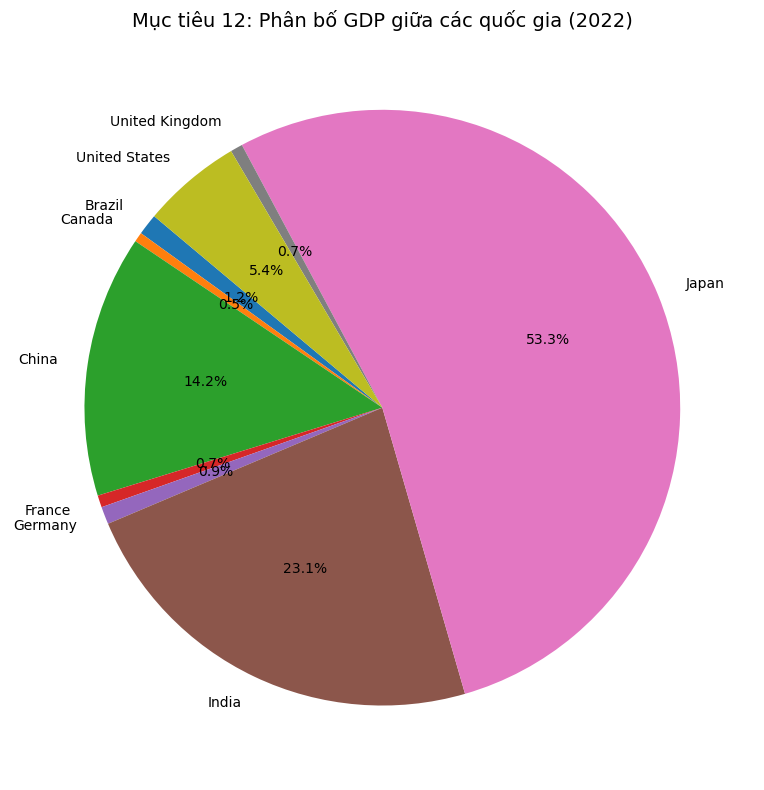

In [24]:
gdp_latest = gdp_grouped[gdp_grouped['Year'] == target_year]
gdp_latest = gdp_latest[gdp_latest['Country Name'].isin(relevant_country_names)]

plt.figure(figsize=(8, 8))
plt.pie(gdp_latest['Value'], labels=gdp_latest['Country Name'], autopct='%1.1f%%', startangle=140)
plt.title(f'Mục tiêu 12: Phân bố GDP giữa các quốc gia ({target_year})', fontsize=14)
plt.tight_layout()
plt.show()

#### **Lựa chọn biểu đồ**
- **Biểu đồ được chọn:** Biểu đồ tròn (Pie Chart)
- **Lý do:**
  - **Tính chất dữ liệu:** Dữ liệu là GDP (Value) của từng quốc gia, và chúng ta muốn xem tỷ lệ đóng góp của từng quốc gia vào tổng GDP.
  - **Mục tiêu phân tích:** Hiển thị phân bố GDP giữa các quốc gia, giúp nhận diện quốc gia nào đóng góp nhiều nhất vào tổng GDP.

#### **Nhận xét**